In [1]:
#!rm -rf /kaggle/working/*

# Imports

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import zipfile
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import cv2
from pathlib import Path


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

2025-06-28 04:45:18.499127: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751085918.768003      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751085918.844167      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


/kaggle/input/dogs-vs-cats/test1.zip
/kaggle/input/dogs-vs-cats/train.zip
/kaggle/input/dogs-vs-cats/sampleSubmission.csv


# Problem Statement and Data

Figure out if an image is a cat or dog, 1 = Dog and 0 = cat. The training archive contains 25,000 images of dogs and cats. Apparently machine classifiers can score above 80% accuracy on this task. My goal as a novice is to get as close to 80% as I can. 



# Importing Data

In [3]:
# Extract the zip file
def extract_zip(zip_path, extract_to):
    abs_path = os.path.abspath(extract_to)
    
    if not os.path.exists(abs_path):
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_to)
        print("Extracted to: ", extract_to)
    else:
        print("Data already loaded for: ", zip_path)

    zip_dir = os.path.basename(zip_path)
    zip_name = os.path.splitext(zip_dir)[0]
    jpg_path = os.path.join(abs_path, zip_name)

    return jpg_path

# Extract your data
train_path = extract_zip('/kaggle/input/dogs-vs-cats/train.zip', './train_ext')
test_path = extract_zip('/kaggle/input/dogs-vs-cats/test1.zip', './test_ext')

Extracted to:  ./train_ext
Extracted to:  ./test_ext


# Data Exploration

## Look at a few images

Total training images:  25000
Total test images:  12500


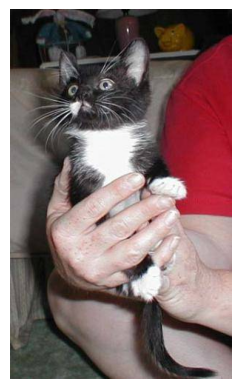

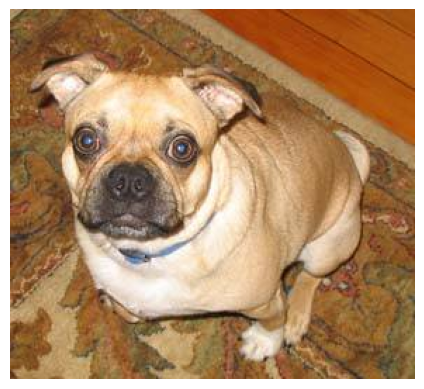

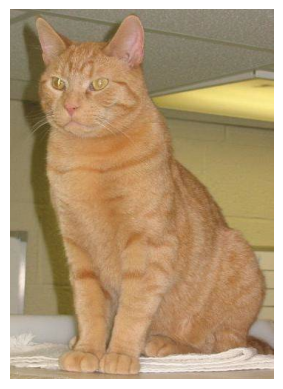

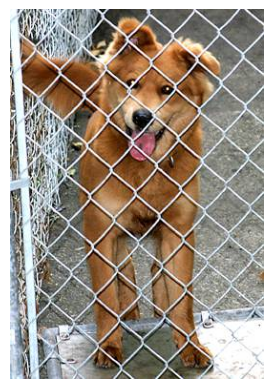

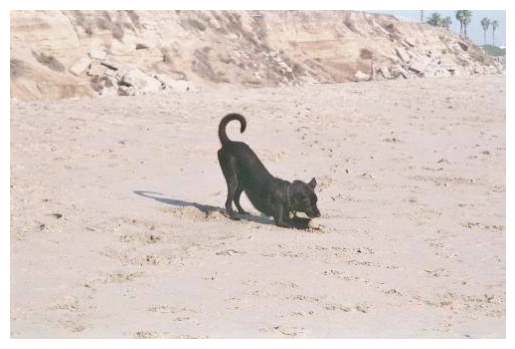

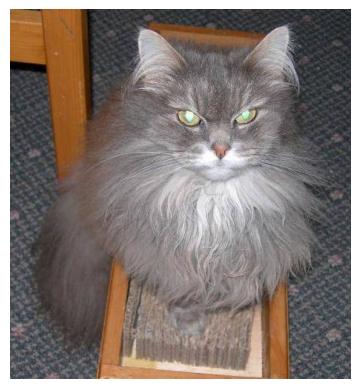

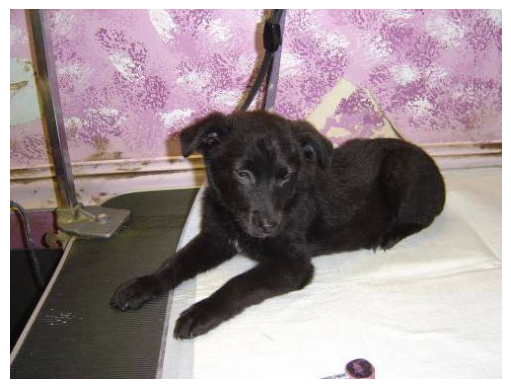

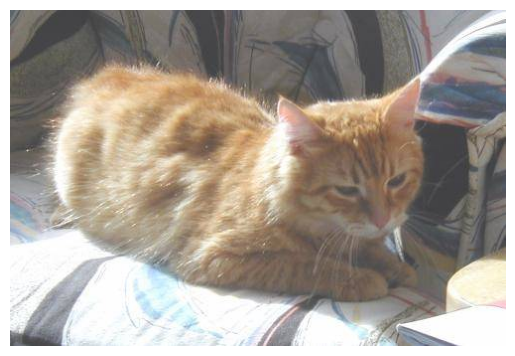

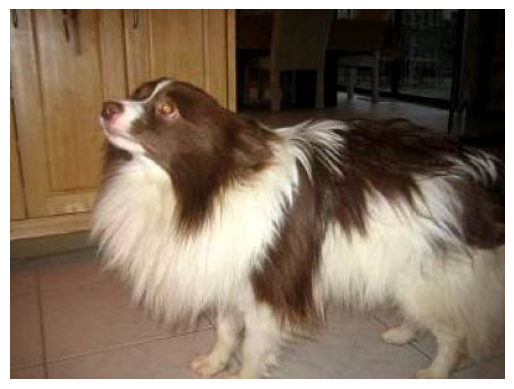

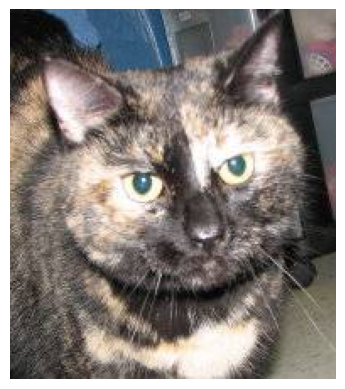

In [4]:
train_files = [f.name for f in Path(train_path).glob("*.jpg")]
test_files  = [f.name for f in Path(test_path).glob("*.jpg")]

print("Total training images: ", len(train_files))
print("Total test images: ", len(test_files))

for i in range(10):
    # Randomly select a image to show
    rand_idx = random.randint(1, 25000)
    jpg_file = train_files[rand_idx]
    jpg_file = os.path.join(train_path, jpg_file)

    # Plot Image
    img = mpimg.imread(jpg_file)
    plt.imshow(img)
    plt.axis('off')  # Hide axes
    plt.show()


2 classes: Cats and Dogs


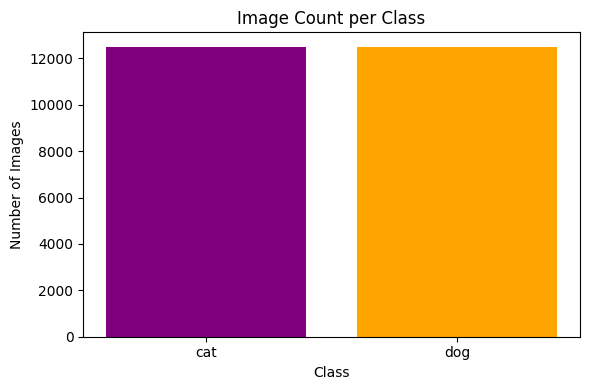

In [5]:
cat_files = [x for x in train_files if 'cat' in x]
dog_files = [x for x in train_files if 'dog' in x]
class_len = len(cat_files) + len(dog_files)

if class_len != len(train_files):
    print("missing classes")
else:
    print("2 classes: Cats and Dogs")
      
# Count
counts = {'cat': len(cat_files), 'dog': len(dog_files)}

# Plot
plt.figure(figsize=(6, 4))
plt.bar(counts.keys(), counts.values(), color=['purple', 'orange'])
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Image Count per Class")
plt.tight_layout()
plt.show()

# Image Information

In [6]:
train_jpg_abs = [os.path.join(train_path, x) for x in train_files]
data = []
for jpg in train_jpg_abs:
    try:
        img = cv2.imread(jpg)
        height, width, channels = img.shape
        data.append({
                "filename": jpg,
                "height": height,
                "width": width,
                "channels": channels
            })
    except Exception as e:
        print(f"Error reading {jpg}: {e}")

In [7]:
df = pd.DataFrame(data)
print("Head:\n", df.head())
print("\n")
print("Shape:\n ", df.shape)
print("\n")
print("Info:\n")
df.info()
print("\n")
print("Describe:\n", df.describe())

Head:
                                        filename  height  width  channels
0  /kaggle/working/train_ext/train/dog.7987.jpg     240    264         3
1   /kaggle/working/train_ext/train/dog.433.jpg     239    320         3
2  /kaggle/working/train_ext/train/dog.4658.jpg     401    350         3
3  /kaggle/working/train_ext/train/cat.6768.jpg     272    359         3
4  /kaggle/working/train_ext/train/dog.6324.jpg     499    431         3


Shape:
  (25000, 4)


Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  25000 non-null  object
 1   height    25000 non-null  int64 
 2   width     25000 non-null  int64 
 3   channels  25000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 781.4+ KB


Describe:
              height        width  channels
count  25000.000000  25000.00000   25000.0
mean     360.478080    404.09904     